# CMA-ES: Covariance Matrix Adaptation Evolution Strategy

This notebook builds up an intuition for **CMA-ES** — the gold-standard
derivative-free optimiser for continuous search spaces — and shows why it
matters for portfolio optimisation.

**Road-map**
1. Why isotropic noise is wasteful
2. CMA-ES from scratch on a toy 2-D landscape
3. Visualising the covariance ellipse as it adapts
4. Comparing convergence: isotropic vs CMA-ES
5. CMA-ES on a portfolio-shaped problem
6. Where to go next — multi-objective CMA-ES

In [1]:
import warnings, sys
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from matplotlib.colors import LogNorm
import seaborn as sns

# ── Global plot style (matches populations.ipynb) ─────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150,
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
PALETTE = sns.color_palette('colorblind')
rng = np.random.default_rng(42)

In [2]:
# ── Helper: draw a covariance ellipse ─────────────────────────────────────
def cov_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """Draw an ellipse representing `n_std` standard deviations of `cov`."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(eigvals)
    ell = Ellipse(xy=mean, width=w, height=h, angle=angle, **kwargs)
    ax.add_patch(ell)
    return ell

# ── Test functions ────────────────────────────────────────────────────────
def rosenbrock(x):
    """Rosenbrock (banana) — classic hard landscape with a curved valley."""
    return (1 - x[:, 0])**2 + 100 * (x[:, 1] - x[:, 0]**2)**2

def rotated_ellipsoid(x, condition=50):
    """Ellipsoid rotated 45 degrees — illustrates axis-aligned vs adapted search."""
    theta = np.pi / 4
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    xr = x @ R.T
    return xr[:, 0]**2 + condition * xr[:, 1]**2

print("Helpers ready.")

Helpers ready.


## 1. The Problem with Isotropic Noise

Your current `breed()` method adds **spherical** Gaussian noise — the same
step size in every direction. On a landscape whose contours are *not* circular
this wastes most samples exploring directions that don't improve fitness.

Below we draw the **rotated ellipsoid** — a simple function whose optimal
valley runs diagonally. An isotropic search cloud (left) spreads effort
equally; an *adapted* ellipse (right) concentrates samples along the valley.

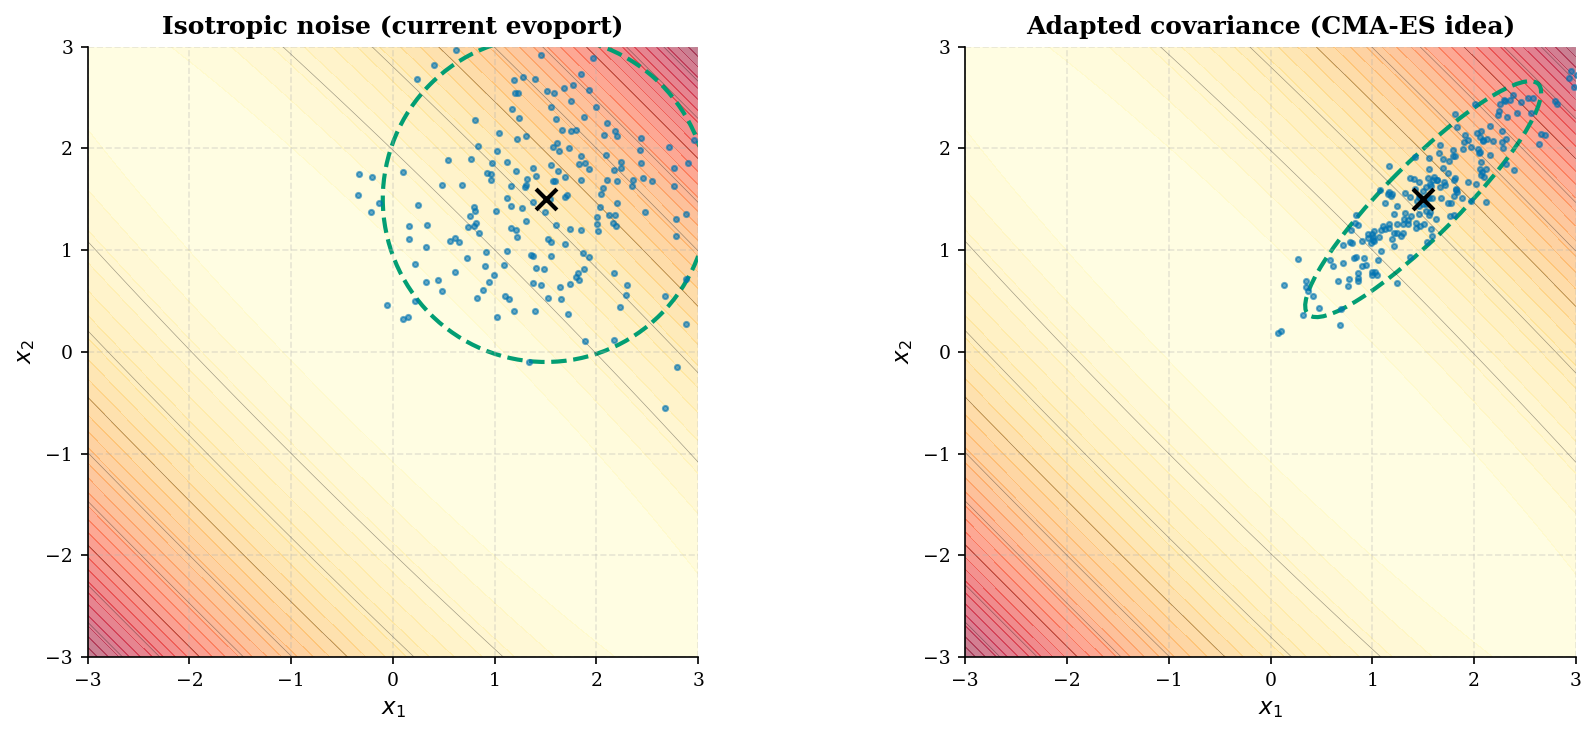

In [3]:
# ── Figure 1: Isotropic vs adapted sampling on a rotated ellipsoid ────────
grid = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(grid, grid)
Z = rotated_ellipsoid(np.c_[X.ravel(), Y.ravel()]).reshape(X.shape)

mean = np.array([1.5, 1.5])
sigma = 0.8

# Isotropic covariance (identity)
C_iso = np.eye(2)
samples_iso = rng.multivariate_normal(mean, (sigma**2) * C_iso, size=200)

# Adapted covariance (aligned with the valley)
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
C_adapted = R @ np.diag([1.0, 0.05]) @ R.T
samples_adapt = rng.multivariate_normal(mean, (sigma**2) * C_adapted, size=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, samples, C, title in zip(
    axes,
    [samples_iso, samples_adapt],
    [C_iso, C_adapted],
    ['Isotropic noise (current evoport)', 'Adapted covariance (CMA-ES idea)'],
):
    ax.contourf(X, Y, Z, levels=30, cmap='YlOrRd', alpha=0.5)
    ax.contour(X, Y, Z, levels=10, colors='k', linewidths=0.3, alpha=0.4)
    ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.6,
               color=PALETTE[0], zorder=3)
    ax.scatter(*mean, marker='x', s=100, color='k', linewidths=2, zorder=4)
    cov_ellipse(mean, (sigma**2) * C, ax, n_std=2,
                facecolor='none', edgecolor=PALETTE[2], linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')

fig.tight_layout()
plt.show()

## 2. CMA-ES from Scratch

CMA-ES maintains three pieces of state that it updates every generation:

| Symbol | Meaning | Intuition |
|--------|---------|-----------|
| $\mathbf{m}$ | Distribution mean | "Where are we searching?" |
| $\sigma$ | Global step size | "How far do we step?" |
| $\mathbf{C}$ | Covariance matrix | "In which *shape* do we step?" |

**One generation:**
1. **Sample** $\lambda$ candidates: $x_i = m + \sigma \cdot \mathcal{N}(0, C)$
2. **Rank** by fitness, keep the best $\mu$
3. **Update $m$** $\leftarrow$ weighted mean of best $\mu$ candidates
4. **Update $C$** to stretch toward directions that produced good samples
5. **Update $\sigma$** via a *cumulative step-size adaptation path* (CSA)

The magic is in steps 4-5. Two "evolution paths" track momentum:
- **$p_\sigma$** (step-size path): if successive mean-shifts point the same way, the algorithm is making progress → *increase* $\sigma$. If they cancel, we're oscillating → *decrease* $\sigma$.
- **$p_c$** (covariance path): a smoothed history of mean-shifts, used as a rank-1 update to $C$ so it learns long-range correlations.

In [4]:
class CMA_ES:
    """
    Minimal CMA-ES implementation for educational purposes.
    Follows the (mu/mu_w, lambda) variant from Hansen (2016).
    """

    def __init__(self, mean, sigma, lam=None, seed=42):
        self.dim = len(mean)
        self.mean = np.array(mean, dtype=float)
        self.sigma = sigma

        # ── Population sizes ──────────────────────────────────────────
        self.lam = lam or 4 + int(3 * np.log(self.dim))   # offspring
        self.mu = self.lam // 2                             # parents

        # ── Recombination weights (log-linear) ────────────────────────
        weights = np.log(self.mu + 0.5) - np.log(np.arange(1, self.mu + 1))
        self.weights = weights / weights.sum()
        self.mu_eff = 1.0 / (self.weights ** 2).sum()

        # ── Step-size adaptation constants ────────────────────────────
        self.c_sigma = (self.mu_eff + 2) / (self.dim + self.mu_eff + 5)
        self.d_sigma = 1 + 2 * max(0, np.sqrt((self.mu_eff - 1) / (self.dim + 1)) - 1) + self.c_sigma
        self.chi_n = np.sqrt(self.dim) * (1 - 1/(4*self.dim) + 1/(21*self.dim**2))

        # ── Covariance adaptation constants ───────────────────────────
        self.cc = (4 + self.mu_eff / self.dim) / (self.dim + 4 + 2 * self.mu_eff / self.dim)
        self.c1 = 2 / ((self.dim + 1.3)**2 + self.mu_eff)
        self.c_mu = min(1 - self.c1,
                        2 * (self.mu_eff - 2 + 1/self.mu_eff) / ((self.dim + 2)**2 + self.mu_eff))

        # ── State ─────────────────────────────────────────────────────
        self.C = np.eye(self.dim)
        self.p_sigma = np.zeros(self.dim)
        self.p_c = np.zeros(self.dim)
        self.rng = np.random.default_rng(seed)

        # ── History (for plotting) ────────────────────────────────────
        self.history = []

    def _record(self, gen, population, fitness):
        self.history.append({
            'gen': gen,
            'mean': self.mean.copy(),
            'sigma': self.sigma,
            'C': self.C.copy(),
            'best_f': fitness.min(),
            'median_f': np.median(fitness),
            'population': population.copy(),
            'fitness': fitness.copy(),
        })

    def step(self, objective, gen=0):
        """Run one generation. `objective(x) -> array of shape (lam,)`."""
        n, lam, mu = self.dim, self.lam, self.mu

        # 1) Sample
        eigvals, B = np.linalg.eigh(self.C)
        D = np.sqrt(np.maximum(eigvals, 1e-20))
        invsqrtC = B @ np.diag(1.0 / D) @ B.T

        z = self.rng.standard_normal((lam, n))
        x = self.mean + self.sigma * (z @ (B * D).T)

        # 2) Rank
        f = objective(x)
        idx = np.argsort(f)
        x_sorted = x[idx]

        # 3) Update mean
        old_mean = self.mean.copy()
        self.mean = self.weights @ x_sorted[:mu]

        # 4) Evolution paths
        mean_shift = (self.mean - old_mean) / self.sigma

        self.p_sigma = ((1 - self.c_sigma) * self.p_sigma
                        + np.sqrt(self.c_sigma * (2 - self.c_sigma) * self.mu_eff)
                        * (invsqrtC @ mean_shift))

        h_sig = (np.linalg.norm(self.p_sigma)
                 / np.sqrt(1 - (1 - self.c_sigma)**(2*(gen+1)))
                 / self.chi_n < 1.4 + 2/(n+1))

        self.p_c = ((1 - self.cc) * self.p_c
                    + h_sig * np.sqrt(self.cc * (2 - self.cc) * self.mu_eff)
                    * mean_shift)

        # 5) Update C
        artmp = (x_sorted[:mu] - old_mean) / self.sigma
        rank_mu_update = (self.weights[:, None] * artmp).T @ artmp
        self.C = ((1 - self.c1 - self.c_mu) * self.C
                  + self.c1 * (np.outer(self.p_c, self.p_c)
                               + (1 - h_sig) * self.cc * (2 - self.cc) * self.C)
                  + self.c_mu * rank_mu_update)

        # 6) Update sigma
        self.sigma *= np.exp((self.c_sigma / self.d_sigma)
                             * (np.linalg.norm(self.p_sigma) / self.chi_n - 1))

        self._record(gen, x, f)
        return self

    def run(self, objective, n_generations):
        for g in range(n_generations):
            self.step(objective, gen=g)
        return self

print("CMA_ES class ready.")

CMA_ES class ready.


## 3. Running CMA-ES on the Rotated Ellipsoid

Let's watch CMA-ES learn the shape of the landscape. The ellipse starts as a
circle (identity covariance) and rotates + stretches to align with the valley.

In [5]:
# ── Run CMA-ES on the rotated ellipsoid ───────────────────────────────────
cma = CMA_ES(mean=[2.0, 2.0], sigma=1.0, lam=20, seed=42)
cma.run(rotated_ellipsoid, n_generations=40)

print(f"Final mean:  ({cma.mean[0]:.4f}, {cma.mean[1]:.4f})")
print(f"Final sigma: {cma.sigma:.4f}")
print(f"Best f:      {cma.history[-1]['best_f']:.6f}")

Final mean:  (-0.0000, 0.0000)
Final sigma: 0.0090
Best f:      0.000000


### Figure 2 — Covariance Ellipse Evolution

Each panel shows one generation: the contour landscape, the sampled population
(dots), the distribution mean (cross), and the 2-$\sigma$ search ellipse.
Watch the ellipse rotate from a circle into a thin sliver aligned with the
valley's principal axis.

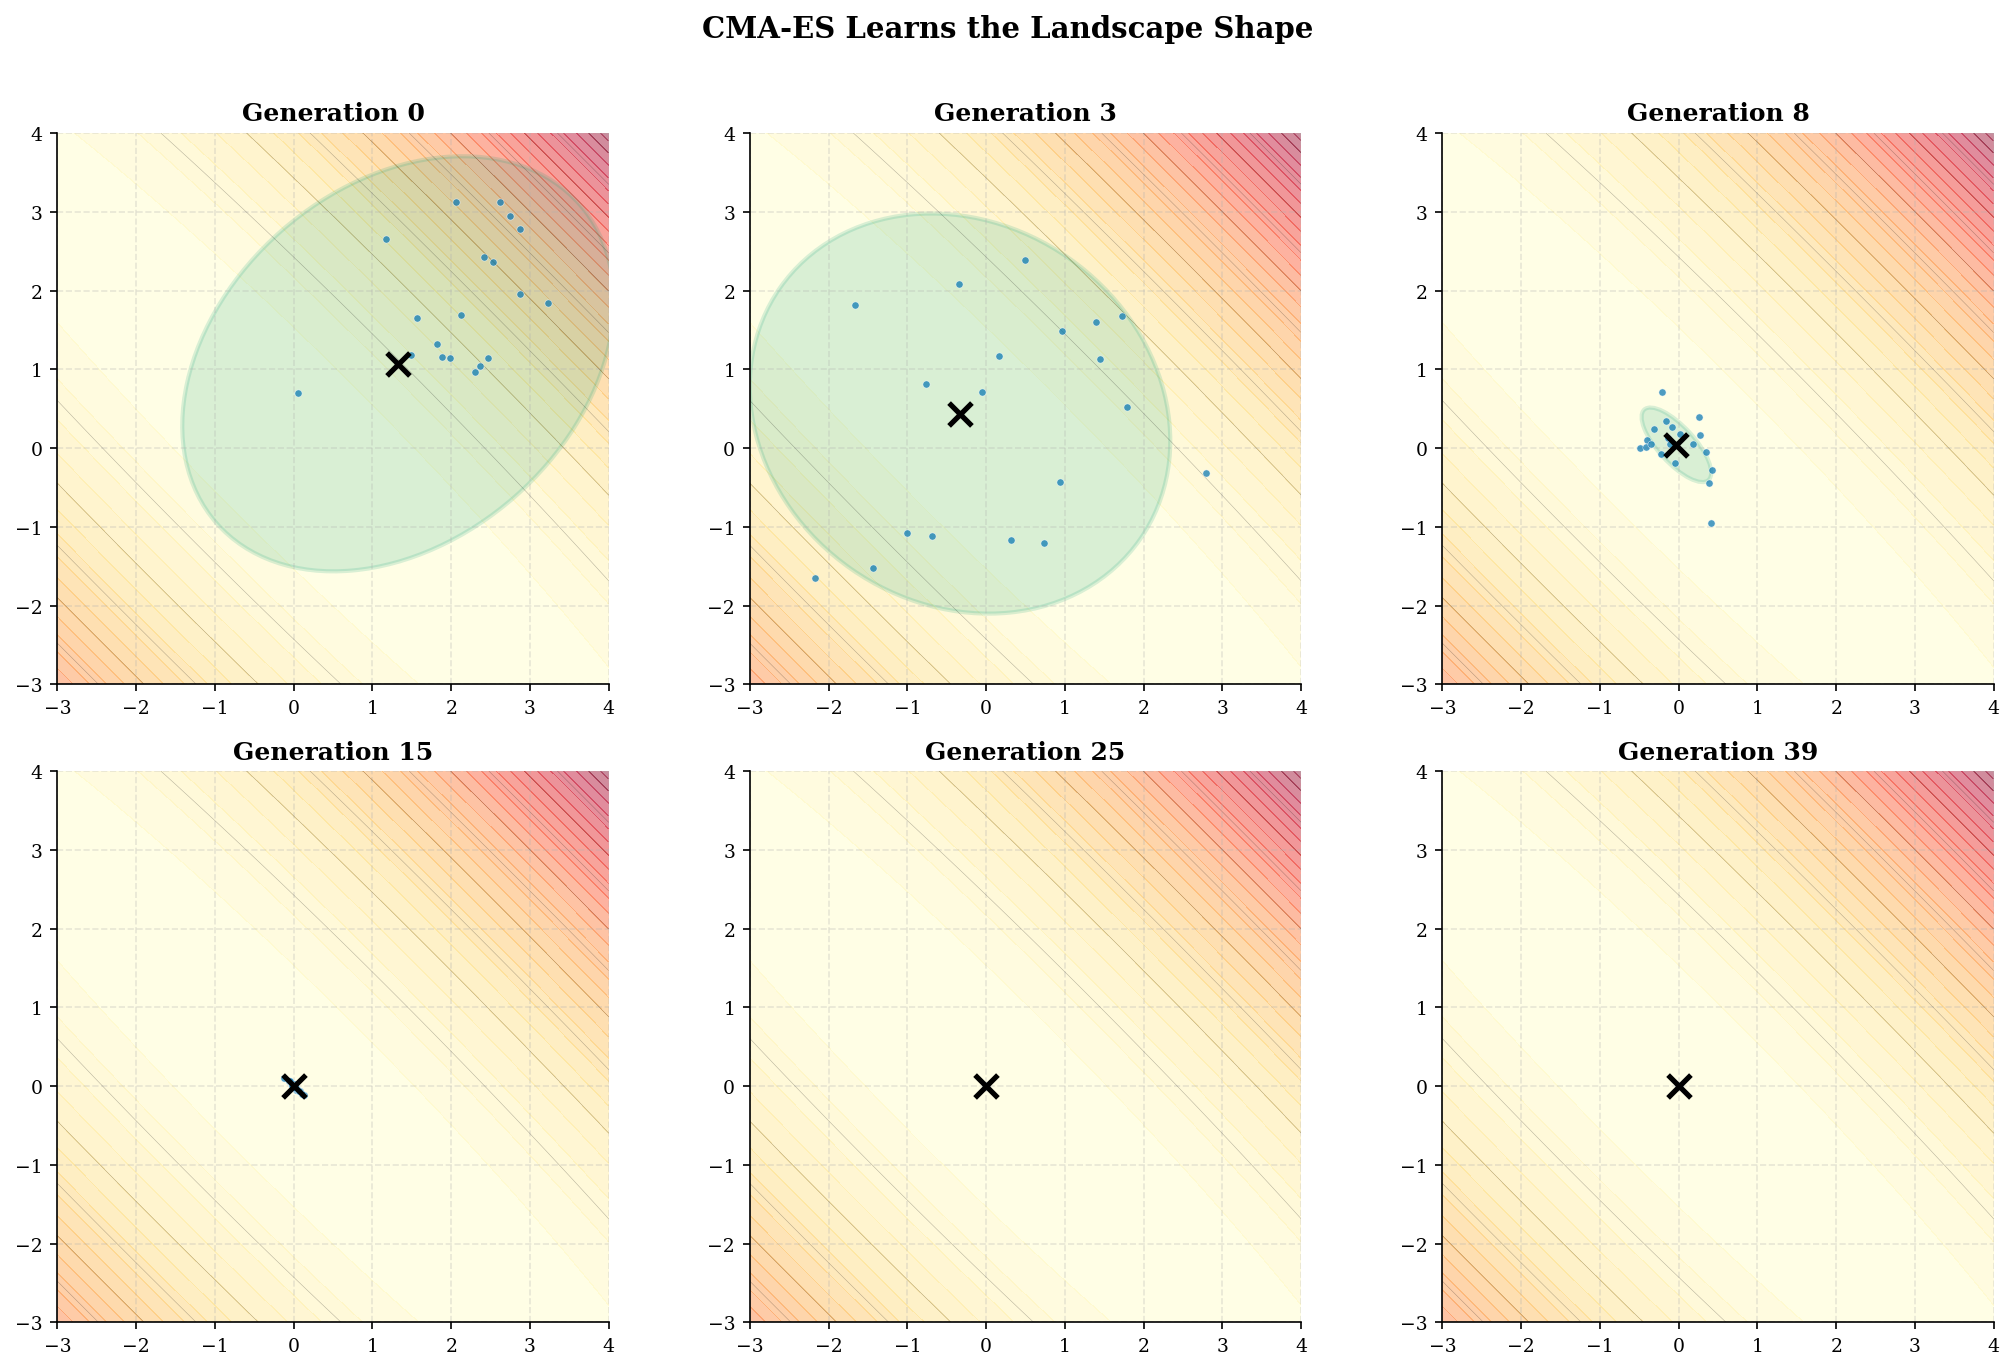

In [6]:
# ── Figure 2: Ellipse snapshots across generations ────────────────────────
show_gens = [0, 3, 8, 15, 25, 39]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

grid = np.linspace(-3, 4, 300)
X, Y = np.meshgrid(grid, grid)
Z = rotated_ellipsoid(np.c_[X.ravel(), Y.ravel()]).reshape(X.shape)

for ax, g in zip(axes.flat, show_gens):
    h = cma.history[g]
    ax.contourf(X, Y, Z, levels=30, cmap='YlOrRd', alpha=0.45)
    ax.contour(X, Y, Z, levels=12, colors='k', linewidths=0.25, alpha=0.3)

    pop = h['population']
    ax.scatter(pop[:, 0], pop[:, 1], s=12, alpha=0.7, color=PALETTE[0],
               edgecolors='white', linewidths=0.3, zorder=3)
    ax.scatter(*h['mean'], marker='x', s=120, color='k', linewidths=2.5, zorder=5)

    cov_ellipse(h['mean'], (h['sigma']**2) * h['C'], ax, n_std=2,
                facecolor=PALETTE[2], alpha=0.15, edgecolor=PALETTE[2], linewidth=2)

    ax.set_title(f"Generation {g}", fontweight='bold')
    ax.set_xlim(-3, 4); ax.set_ylim(-3, 4)
    ax.set_aspect('equal')

fig.suptitle('CMA-ES Learns the Landscape Shape', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Figure 3 — Mean Trajectory

The path the distribution mean takes as it converges to the optimum at $(0, 0)$.

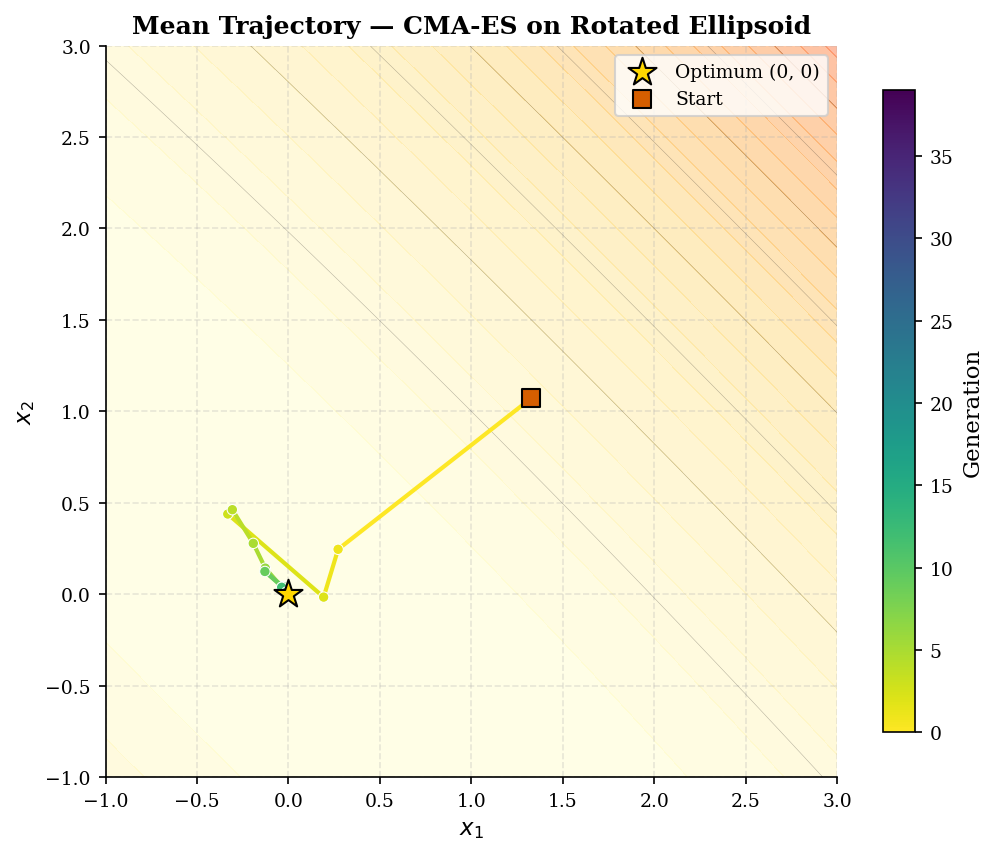

In [7]:
# ── Figure 3: Mean trajectory over the contour landscape ──────────────────
means = np.array([h['mean'] for h in cma.history])

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(X, Y, Z, levels=40, cmap='YlOrRd', alpha=0.45)
ax.contour(X, Y, Z, levels=15, colors='k', linewidths=0.25, alpha=0.3)

# Colour the path by generation
colors = plt.cm.viridis_r(np.linspace(0, 1, len(means)))
for i in range(len(means) - 1):
    ax.plot(means[i:i+2, 0], means[i:i+2, 1], color=colors[i], linewidth=2, zorder=4)
ax.scatter(means[:, 0], means[:, 1], c=np.arange(len(means)),
           cmap='viridis_r', s=25, edgecolors='white', linewidths=0.5, zorder=5)
ax.scatter(0, 0, marker='*', s=200, color='gold', edgecolors='k', linewidths=1, zorder=6,
           label='Optimum (0, 0)')
ax.scatter(*means[0], marker='s', s=80, color=PALETTE[3], edgecolors='k', zorder=6,
           label='Start')

sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(0, len(means)-1))
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Generation')

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Mean Trajectory — CMA-ES on Rotated Ellipsoid', fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(-1, 3); ax.set_ylim(-1, 3)
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

### Figure 4 — Sigma and Covariance Internals

Three diagnostic plots that reveal *how* CMA-ES adapts:

- **Best & median fitness** — convergence speed
- **Step size $\sigma$** — the algorithm's "confidence" in its current scale
- **Eigenvalue ratio** of $C$ — how elongated the search ellipse is (1 = circle, large = thin cigar)

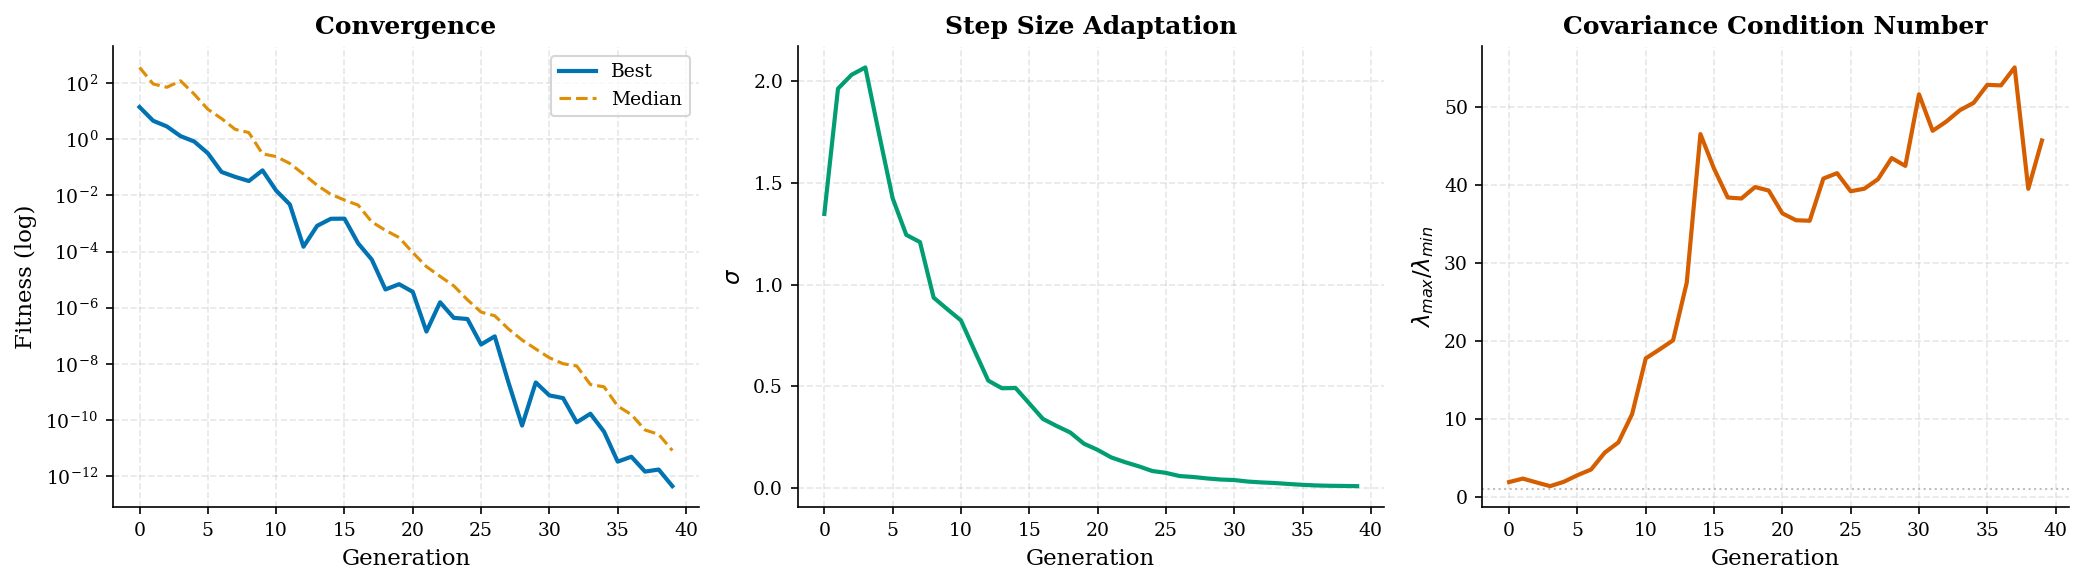

In [8]:
# ── Figure 4: Diagnostics — fitness, sigma, eigenvalue ratio ──────────────
gens     = [h['gen'] for h in cma.history]
best_f   = [h['best_f'] for h in cma.history]
median_f = [h['median_f'] for h in cma.history]
sigmas   = [h['sigma'] for h in cma.history]

eig_ratios = []
for h in cma.history:
    ev = np.linalg.eigvalsh(h['C'])
    eig_ratios.append(ev.max() / max(ev.min(), 1e-20))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Fitness
ax = axes[0]
ax.semilogy(gens, best_f, color=PALETTE[0], linewidth=2, label='Best')
ax.semilogy(gens, median_f, color=PALETTE[1], linewidth=1.5, linestyle='--', label='Median')
ax.set_xlabel('Generation'); ax.set_ylabel('Fitness (log)')
ax.set_title('Convergence', fontweight='bold')
ax.legend()

# Sigma
ax = axes[1]
ax.plot(gens, sigmas, color=PALETTE[2], linewidth=2)
ax.set_xlabel('Generation'); ax.set_ylabel('$\\sigma$')
ax.set_title('Step Size Adaptation', fontweight='bold')

# Condition number
ax = axes[2]
ax.plot(gens, eig_ratios, color=PALETTE[3], linewidth=2)
ax.set_xlabel('Generation'); ax.set_ylabel('$\\lambda_{max} / \\lambda_{min}$')
ax.set_title('Covariance Condition Number', fontweight='bold')
ax.axhline(1, color='grey', linestyle=':', linewidth=1, alpha=0.5)

fig.tight_layout()
plt.show()

## 4. CMA-ES vs Isotropic Gaussian Evolution

Now let's implement a **simple isotropic evolution** (similar to evoport's
current `breed()`) and race it against CMA-ES on the same problem.
This makes the advantage concrete.

In [9]:
class IsotropicES:
    """
    Simple (mu, lambda) ES with fixed isotropic Gaussian noise.
    This mirrors evoport's current breeding strategy.
    """

    def __init__(self, mean, sigma, lam=20, seed=42):
        self.dim = len(mean)
        self.mean = np.array(mean, dtype=float)
        self.sigma = sigma
        self.lam = lam
        self.mu = lam // 2
        self.rng = np.random.default_rng(seed)
        self.history = []

    def run(self, objective, n_generations):
        for g in range(n_generations):
            # Sample isotropically
            noise = self.rng.standard_normal((self.lam, self.dim))
            x = self.mean + self.sigma * noise

            # Rank and select
            f = objective(x)
            idx = np.argsort(f)[:self.mu]

            # Update mean (simple average of best)
            self.mean = x[idx].mean(axis=0)

            self.history.append({
                'gen': g,
                'mean': self.mean.copy(),
                'best_f': f[idx[0]],
                'median_f': np.median(f),
                'population': x.copy(),
                'fitness': f.copy(),
            })
        return self


# ── Race both algorithms on the rotated ellipsoid ─────────────────────────
N_GEN = 40

cma_runner   = CMA_ES(mean=[2.0, 2.0], sigma=1.0, lam=20, seed=42)
cma_runner.run(rotated_ellipsoid, N_GEN)

iso_runner   = IsotropicES(mean=[2.0, 2.0], sigma=1.0, lam=20, seed=42)
iso_runner.run(rotated_ellipsoid, N_GEN)

print(f"CMA-ES     final best: {cma_runner.history[-1]['best_f']:.8f}")
print(f"Isotropic  final best: {iso_runner.history[-1]['best_f']:.8f}")

CMA-ES     final best: 0.00000000
Isotropic  final best: 1.39827388


### Figure 5 — Convergence Comparison

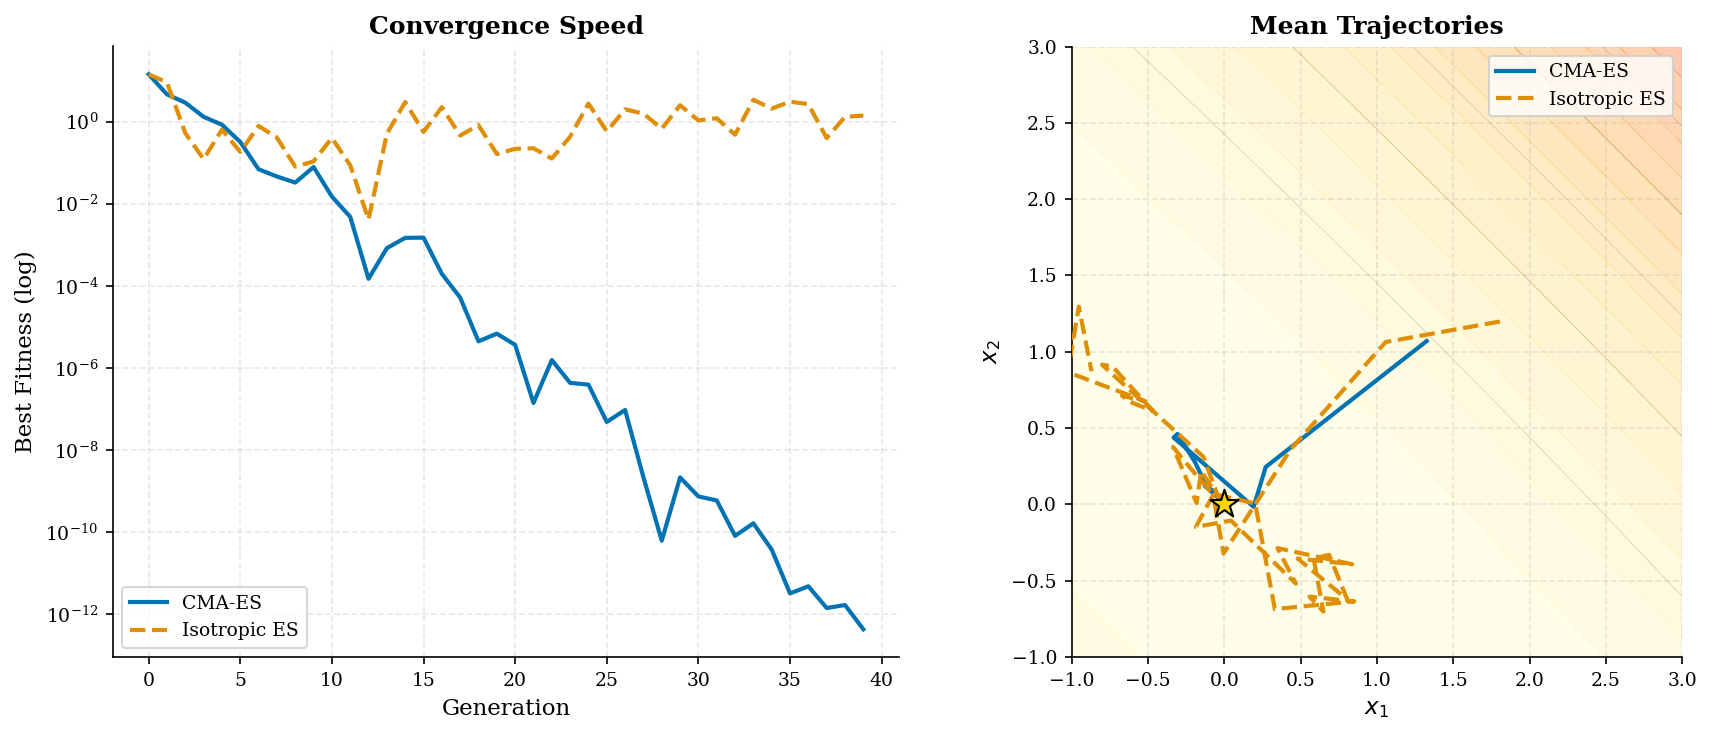

In [10]:
# ── Figure 5: Convergence — CMA-ES vs Isotropic ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Best fitness over generations
ax = axes[0]
ax.semilogy([h['gen'] for h in cma_runner.history],
            [h['best_f'] for h in cma_runner.history],
            color=PALETTE[0], linewidth=2, label='CMA-ES')
ax.semilogy([h['gen'] for h in iso_runner.history],
            [h['best_f'] for h in iso_runner.history],
            color=PALETTE[1], linewidth=2, linestyle='--', label='Isotropic ES')
ax.set_xlabel('Generation'); ax.set_ylabel('Best Fitness (log)')
ax.set_title('Convergence Speed', fontweight='bold')
ax.legend()

# (b) Side-by-side trajectories on contour
ax = axes[1]
ax.contourf(X, Y, Z, levels=30, cmap='YlOrRd', alpha=0.4)
ax.contour(X, Y, Z, levels=10, colors='k', linewidths=0.2, alpha=0.3)

m_cma = np.array([h['mean'] for h in cma_runner.history])
m_iso = np.array([h['mean'] for h in iso_runner.history])

ax.plot(m_cma[:, 0], m_cma[:, 1], color=PALETTE[0], linewidth=2,
        label='CMA-ES', zorder=4)
ax.plot(m_iso[:, 0], m_iso[:, 1], color=PALETTE[1], linewidth=2,
        linestyle='--', label='Isotropic ES', zorder=4)
ax.scatter(0, 0, marker='*', s=200, color='gold', edgecolors='k', zorder=6)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Mean Trajectories', fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(-1, 3); ax.set_ylim(-1, 3)
ax.set_aspect('equal')

fig.tight_layout()
plt.show()

### Figure 6 — Population Snapshots Side by Side

Comparing how the two algorithms spread their samples at the same generation.

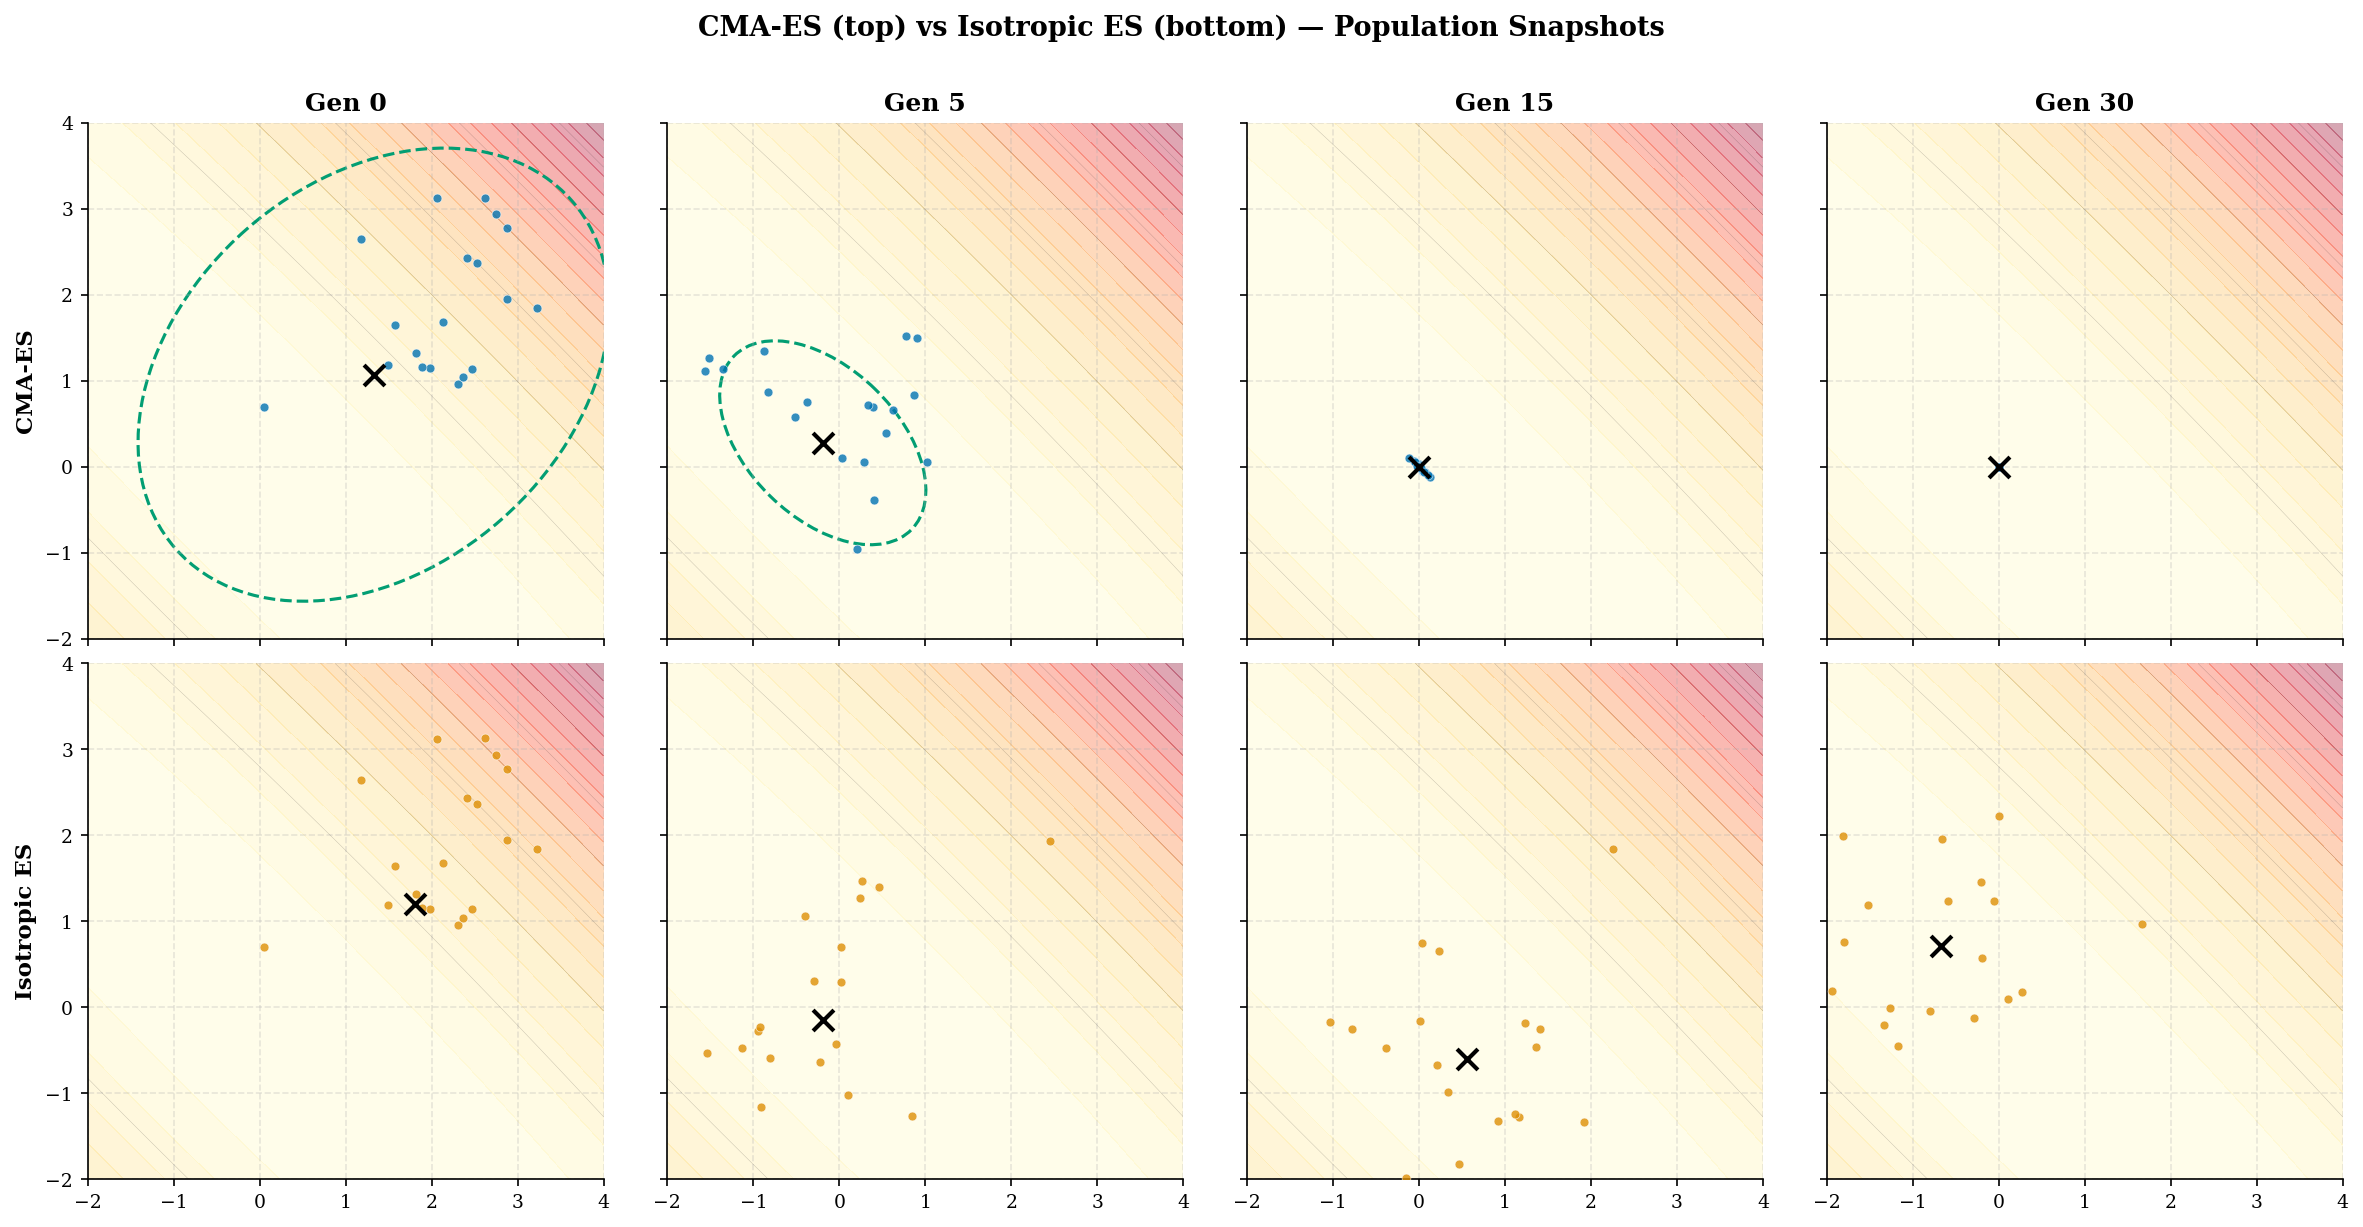

In [11]:
# ── Figure 6: Population snapshots — CMA-ES vs Isotropic at key gens ─────
snap_gens = [0, 5, 15, 30]
fig, axes = plt.subplots(2, len(snap_gens), figsize=(16, 8),
                         sharex=True, sharey=True)

for col, g in enumerate(snap_gens):
    for row, (runner, name, color) in enumerate([
        (cma_runner, 'CMA-ES', PALETTE[0]),
        (iso_runner, 'Isotropic ES', PALETTE[1]),
    ]):
        ax = axes[row, col]
        ax.contourf(X, Y, Z, levels=25, cmap='YlOrRd', alpha=0.35)
        ax.contour(X, Y, Z, levels=8, colors='k', linewidths=0.2, alpha=0.25)

        h = runner.history[g]
        pop = h['population']
        ax.scatter(pop[:, 0], pop[:, 1], s=18, alpha=0.8, color=color,
                   edgecolors='white', linewidths=0.3, zorder=3)
        ax.scatter(*h['mean'], marker='x', s=100, color='k', linewidths=2, zorder=5)

        if row == 0 and hasattr(runner, 'history') and 'C' in h:
            cov_ellipse(h['mean'], (h['sigma']**2) * h['C'], ax, n_std=2,
                        facecolor='none', edgecolor=PALETTE[2], linewidth=1.5,
                        linestyle='--')

        if row == 0:
            ax.set_title(f'Gen {g}', fontweight='bold')
        if col == 0:
            ax.set_ylabel(name, fontweight='bold', fontsize=11)
        ax.set_xlim(-2, 4); ax.set_ylim(-2, 4)
        ax.set_aspect('equal')

fig.suptitle('CMA-ES (top) vs Isotropic ES (bottom) — Population Snapshots',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

## 5. CMA-ES on the Rosenbrock Function

The Rosenbrock "banana" is a much harder landscape — the optimum sits at the
end of a narrow, curved valley. This is where CMA-ES really shines: it bends
its search ellipse to follow the curvature.

In [12]:
# ── Run both on Rosenbrock ─────────────────────────────────────────────────
cma_rb = CMA_ES(mean=[-1.0, -1.0], sigma=1.0, lam=30, seed=99)
cma_rb.run(rosenbrock, n_generations=80)

iso_rb = IsotropicES(mean=[-1.0, -1.0], sigma=1.0, lam=30, seed=99)
iso_rb.run(rosenbrock, n_generations=80)

print(f"CMA-ES     final best: {cma_rb.history[-1]['best_f']:.8f}")
print(f"Isotropic  final best: {iso_rb.history[-1]['best_f']:.8f}")

CMA-ES     final best: 0.00000000
Isotropic  final best: 0.44402867


### Figure 7 — Rosenbrock: Trajectory + Ellipse Evolution

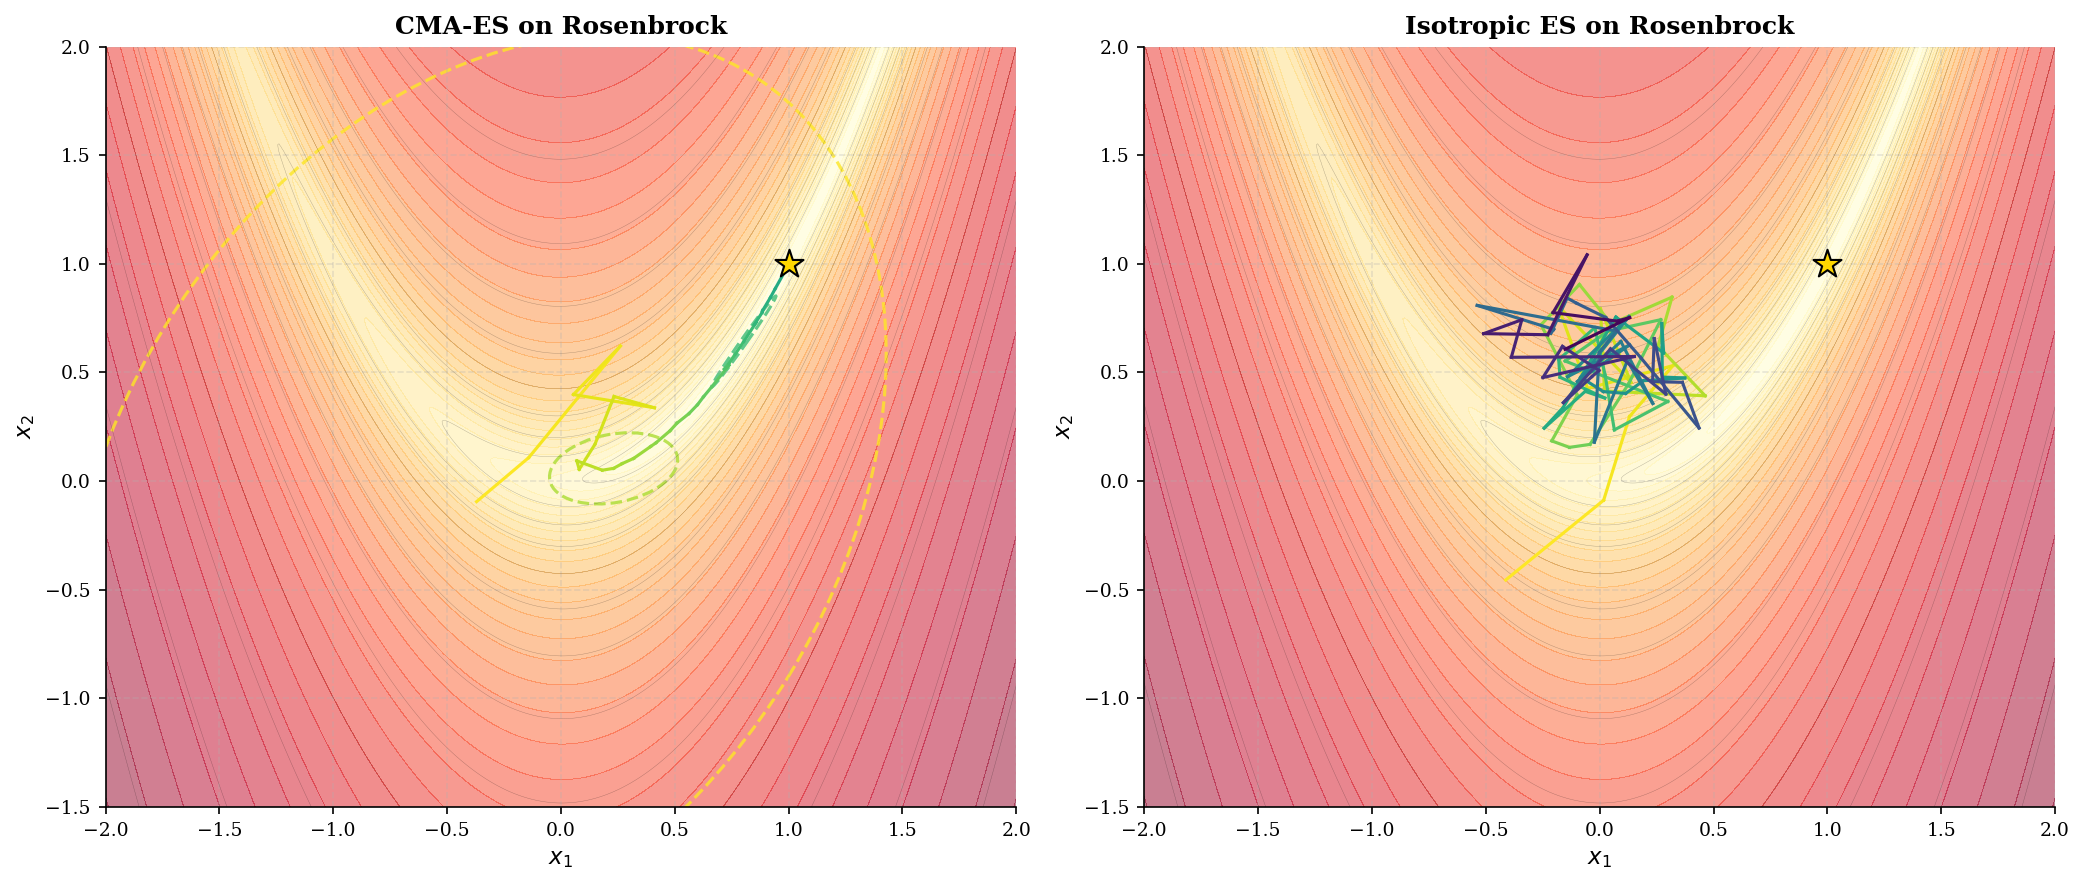

In [13]:
# ── Figure 7: Rosenbrock — CMA-ES trajectory with ellipse snapshots ──────
grid_rb = np.linspace(-2, 2, 400)
Xr, Yr = np.meshgrid(grid_rb, grid_rb)
Zr = rosenbrock(np.c_[Xr.ravel(), Yr.ravel()]).reshape(Xr.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) CMA-ES with ellipses
ax = axes[0]
ax.contourf(Xr, Yr, np.log1p(Zr), levels=35, cmap='YlOrRd', alpha=0.5)
ax.contour(Xr, Yr, np.log1p(Zr), levels=15, colors='k', linewidths=0.2, alpha=0.3)

m_cma_rb = np.array([h['mean'] for h in cma_rb.history])
colors_rb = plt.cm.viridis_r(np.linspace(0, 1, len(m_cma_rb)))
for i in range(len(m_cma_rb) - 1):
    ax.plot(m_cma_rb[i:i+2, 0], m_cma_rb[i:i+2, 1], color=colors_rb[i], linewidth=1.5, zorder=4)

# Draw ellipses at a few generations
for g in [0, 10, 25, 50, 75]:
    if g < len(cma_rb.history):
        h = cma_rb.history[g]
        cov_ellipse(h['mean'], (h['sigma']**2) * h['C'], ax, n_std=1.5,
                    facecolor='none', edgecolor=colors_rb[g], linewidth=1.5,
                    linestyle='--', alpha=0.8)

ax.scatter(1, 1, marker='*', s=200, color='gold', edgecolors='k', zorder=6)
ax.set_title('CMA-ES on Rosenbrock', fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_xlim(-2, 2); ax.set_ylim(-1.5, 2)

# (b) Isotropic ES trajectory
ax = axes[1]
ax.contourf(Xr, Yr, np.log1p(Zr), levels=35, cmap='YlOrRd', alpha=0.5)
ax.contour(Xr, Yr, np.log1p(Zr), levels=15, colors='k', linewidths=0.2, alpha=0.3)

m_iso_rb = np.array([h['mean'] for h in iso_rb.history])
colors_iso = plt.cm.viridis_r(np.linspace(0, 1, len(m_iso_rb)))
for i in range(len(m_iso_rb) - 1):
    ax.plot(m_iso_rb[i:i+2, 0], m_iso_rb[i:i+2, 1], color=colors_iso[i], linewidth=1.5, zorder=4)

ax.scatter(1, 1, marker='*', s=200, color='gold', edgecolors='k', zorder=6)
ax.set_title('Isotropic ES on Rosenbrock', fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_xlim(-2, 2); ax.set_ylim(-1.5, 2)

fig.tight_layout()
plt.show()

### Figure 8 — Rosenbrock Convergence Comparison

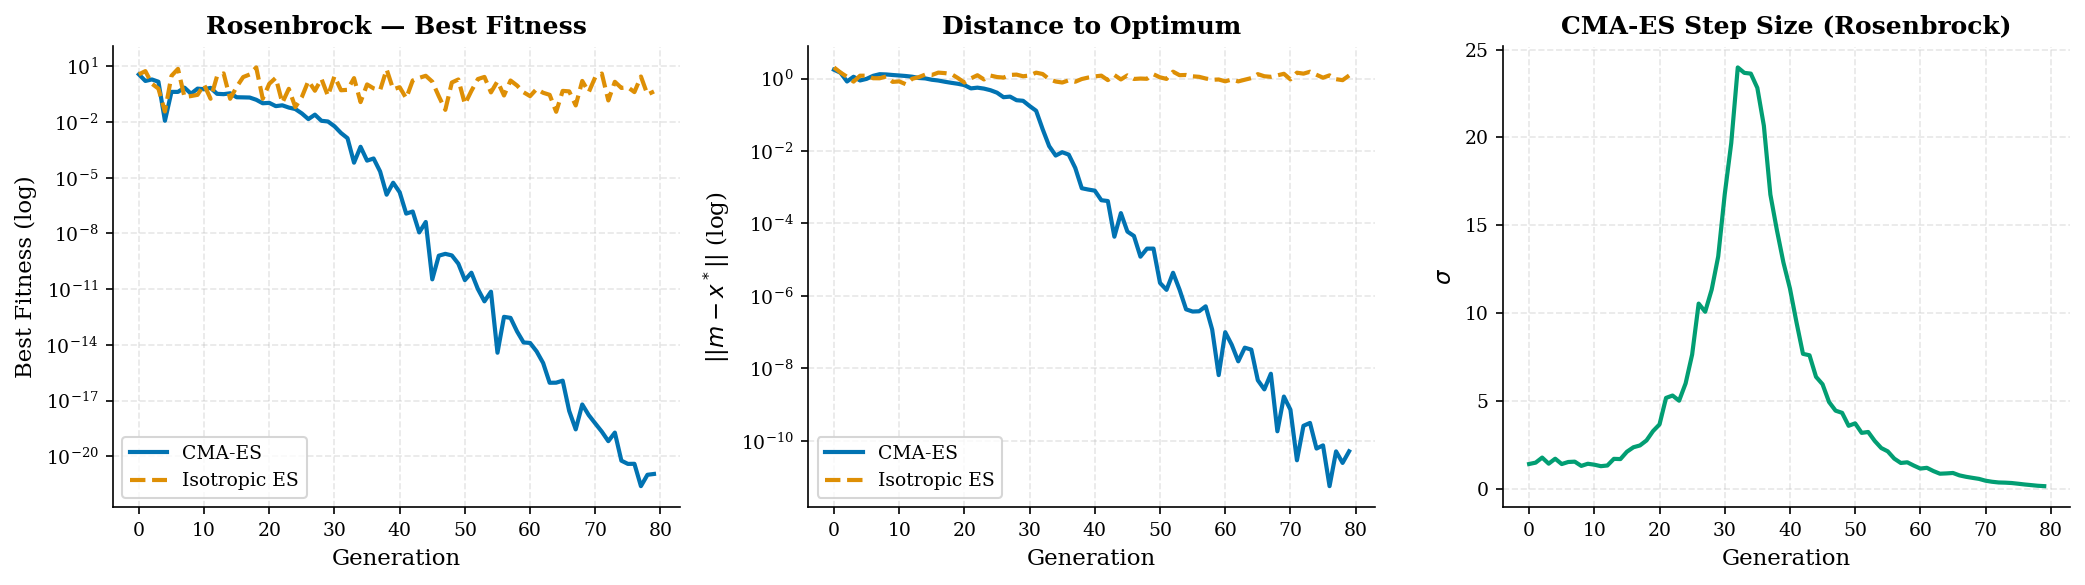

In [14]:
# ── Figure 8: Rosenbrock convergence curves ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Best fitness
ax = axes[0]
ax.semilogy([h['gen'] for h in cma_rb.history],
            [h['best_f'] for h in cma_rb.history],
            color=PALETTE[0], linewidth=2, label='CMA-ES')
ax.semilogy([h['gen'] for h in iso_rb.history],
            [h['best_f'] for h in iso_rb.history],
            color=PALETTE[1], linewidth=2, linestyle='--', label='Isotropic ES')
ax.set_xlabel('Generation'); ax.set_ylabel('Best Fitness (log)')
ax.set_title('Rosenbrock — Best Fitness', fontweight='bold')
ax.legend()

# (b) Distance to optimum
ax = axes[1]
dist_cma = [np.linalg.norm(h['mean'] - np.array([1, 1])) for h in cma_rb.history]
dist_iso = [np.linalg.norm(h['mean'] - np.array([1, 1])) for h in iso_rb.history]
ax.semilogy([h['gen'] for h in cma_rb.history], dist_cma,
            color=PALETTE[0], linewidth=2, label='CMA-ES')
ax.semilogy([h['gen'] for h in iso_rb.history], dist_iso,
            color=PALETTE[1], linewidth=2, linestyle='--', label='Isotropic ES')
ax.set_xlabel('Generation'); ax.set_ylabel('$||m - x^*||$ (log)')
ax.set_title('Distance to Optimum', fontweight='bold')
ax.legend()

# (c) Step size
ax = axes[2]
ax.plot([h['gen'] for h in cma_rb.history],
        [h['sigma'] for h in cma_rb.history],
        color=PALETTE[2], linewidth=2)
ax.set_xlabel('Generation'); ax.set_ylabel('$\\sigma$')
ax.set_title('CMA-ES Step Size (Rosenbrock)', fontweight='bold')

fig.tight_layout()
plt.show()

## 6. CMA-ES on a Portfolio-Shaped Problem

To connect this back to evoport, let's define a **portfolio-like objective** in
2-D weight space: maximise Sharpe ratio (equivalently, minimise negative Sharpe).
We use actual return data from the project to make it realistic.

In [15]:
# ── Build a 2-asset portfolio objective from real data ─────────────────────
import pandas as pd

prices = pd.read_csv('../data/prices.csv', index_col='date')
returns = prices.pct_change().dropna().values[:, :2]  # first 2 assets

def neg_sharpe_2d(w):
    """Negative annualised Sharpe for a 2-asset long-only portfolio."""
    # Softly project onto simplex: clip + normalise
    w_clip = np.clip(w, 0.01, None)
    w_norm = w_clip / w_clip.sum(axis=1, keepdims=True)
    port_ret = returns @ w_norm.T            # (T, lam)
    mu = port_ret.mean(axis=0)
    sigma = port_ret.std(axis=0) + 1e-12
    return -(mu / sigma) * np.sqrt(252)      # minimise = maximise Sharpe

# Landscape on a grid
w1_grid = np.linspace(0.01, 0.99, 200)
w2_grid = 1.0 - w1_grid  # budget constraint
grid_pts = np.column_stack([w1_grid, w2_grid])
sharpe_line = -neg_sharpe_2d(grid_pts)  # positive Sharpe for plotting

print(f"Best grid Sharpe: {sharpe_line.max():.4f} at w1={w1_grid[sharpe_line.argmax()]:.3f}")

Best grid Sharpe: 0.3755 at w1=0.158


In [16]:
# ── Run CMA-ES and Isotropic ES on the portfolio objective ────────────────
cma_port = CMA_ES(mean=[0.5, 0.5], sigma=0.3, lam=20, seed=42)
cma_port.run(neg_sharpe_2d, n_generations=30)

iso_port = IsotropicES(mean=[0.5, 0.5], sigma=0.3, lam=20, seed=42)
iso_port.run(neg_sharpe_2d, n_generations=30)

print(f"CMA-ES  best Sharpe: {-cma_port.history[-1]['best_f']:.4f}")
print(f"Iso ES  best Sharpe: {-iso_port.history[-1]['best_f']:.4f}")

CMA-ES  best Sharpe: 0.3755
Iso ES  best Sharpe: 0.3755


### Figure 9 — Portfolio Sharpe Landscape + Optimiser Paths

Since the budget constraint forces $w_2 = 1 - w_1$, the "landscape" is effectively
1-D. We plot Sharpe as a function of $w_1$ and overlay where each algorithm's
mean lands over generations.

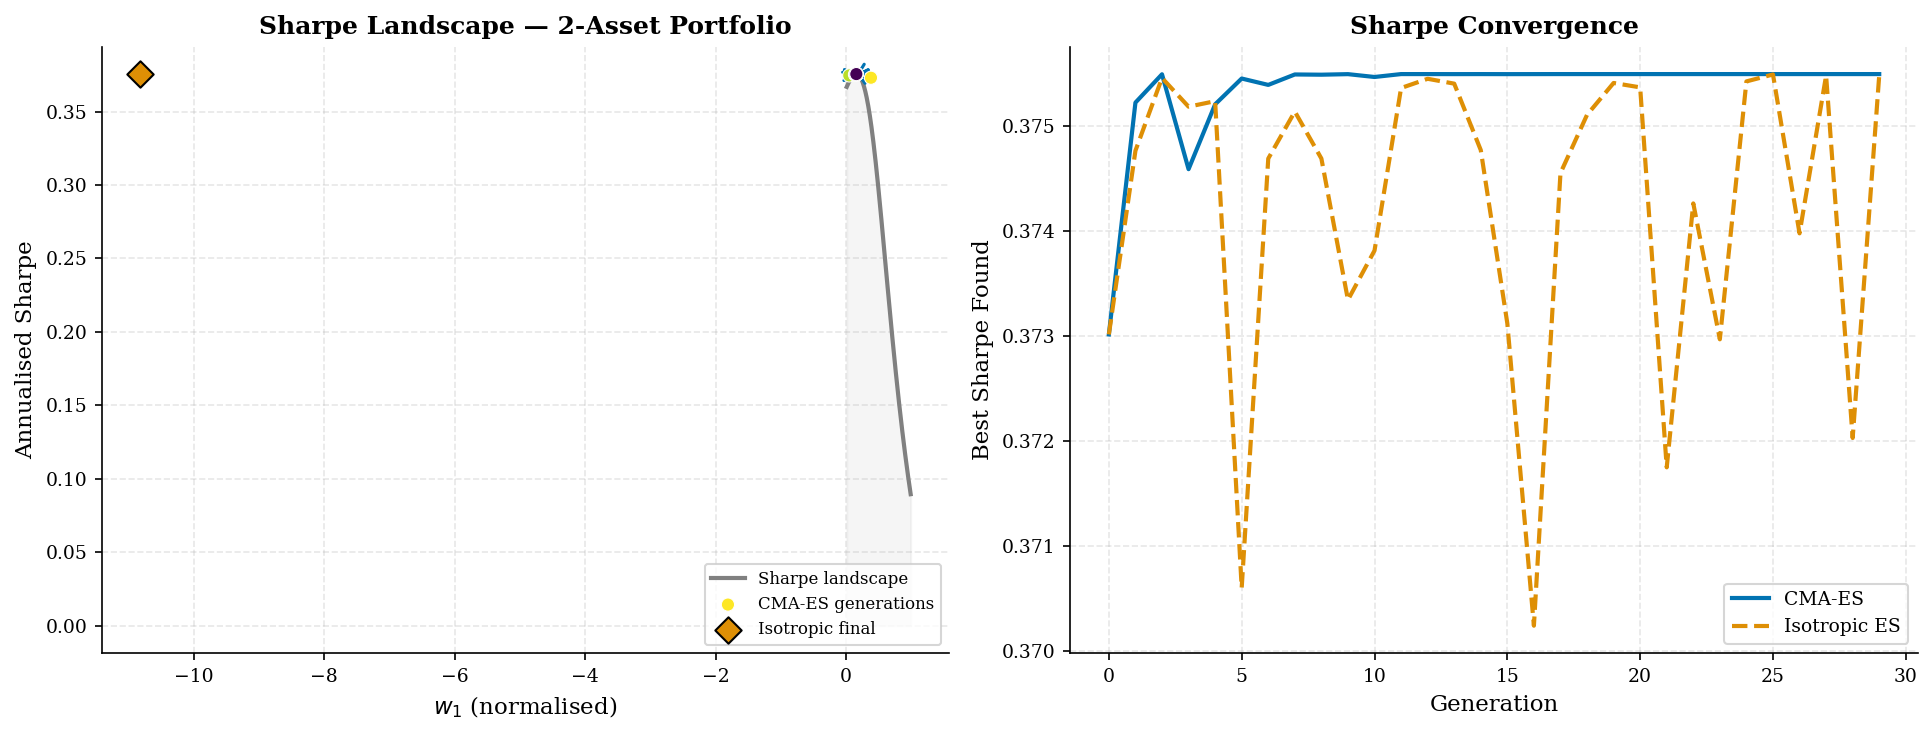

In [17]:
# ── Figure 9: Portfolio Sharpe landscape with optimiser convergence ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Sharpe curve with mean w1 over generations
ax = axes[0]
ax.plot(w1_grid, sharpe_line, color='grey', linewidth=2, label='Sharpe landscape')
ax.fill_between(w1_grid, sharpe_line, alpha=0.08, color='grey')

# CMA-ES mean w1 across generations
cma_w1 = [h['mean'][0] / (h['mean'][0] + h['mean'][1] + 1e-12)
          for h in cma_port.history]
iso_w1 = [h['mean'][0] / (h['mean'][0] + h['mean'][1] + 1e-12)
          for h in iso_port.history]

cma_sharpe = [-h['best_f'] for h in cma_port.history]
iso_sharpe = [-h['best_f'] for h in iso_port.history]

# Mark progression with arrows
for i in range(0, len(cma_w1) - 1, 3):
    ax.annotate('', xy=(cma_w1[i+1], cma_sharpe[i+1]),
                xytext=(cma_w1[i], cma_sharpe[i]),
                arrowprops=dict(arrowstyle='->', color=PALETTE[0], lw=1.5))

ax.scatter(cma_w1, cma_sharpe, c=np.arange(len(cma_w1)),
           cmap='viridis_r', s=40, edgecolors='white', linewidths=0.5,
           zorder=5, label='CMA-ES generations')
ax.scatter(iso_w1[-1], iso_sharpe[-1], marker='D', s=80, color=PALETTE[1],
           edgecolors='k', zorder=6, label=f'Isotropic final')

ax.set_xlabel('$w_1$ (normalised)')
ax.set_ylabel('Annualised Sharpe')
ax.set_title('Sharpe Landscape — 2-Asset Portfolio', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)

# (b) Convergence comparison
ax = axes[1]
ax.plot(range(len(cma_sharpe)), cma_sharpe, color=PALETTE[0], linewidth=2, label='CMA-ES')
ax.plot(range(len(iso_sharpe)), iso_sharpe, color=PALETTE[1], linewidth=2,
        linestyle='--', label='Isotropic ES')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Sharpe Found')
ax.set_title('Sharpe Convergence', fontweight='bold')
ax.legend()

fig.tight_layout()
plt.show()

## 7. Scaling — CMA-ES vs Isotropic in Higher Dimensions

The advantage of CMA-ES grows with dimensionality. Let's run both on the
rotated ellipsoid in 2, 5, 10, and 20 dimensions and measure how many
generations each needs to reach a fitness threshold.

In [18]:
# ── Scaling experiment: N-dimensional rotated ellipsoid ────────────────────
def rotated_ellipsoid_nd(x, condition=50):
    """N-dim rotated ellipsoid with given condition number."""
    n = x.shape[1]
    # Random rotation (fixed seed for reproducibility)
    Q, _ = np.linalg.qr(np.random.default_rng(0).standard_normal((n, n)))
    scales = np.logspace(0, np.log10(condition), n)
    xr = x @ Q
    return (xr**2 * scales).sum(axis=1)

dims = [2, 5, 10, 20]
n_gen_scale = 150
results_scale = {'dim': [], 'algo': [], 'gen': [], 'best_f': []}

for d in dims:
    start = np.ones(d) * 2.0
    lam = 4 + int(3 * np.log(d))
    obj = lambda x: rotated_ellipsoid_nd(x, condition=50)

    # CMA-ES
    c = CMA_ES(mean=start, sigma=1.0, lam=max(lam, 10), seed=42)
    c.run(obj, n_gen_scale)
    for h in c.history:
        results_scale['dim'].append(d)
        results_scale['algo'].append('CMA-ES')
        results_scale['gen'].append(h['gen'])
        results_scale['best_f'].append(h['best_f'])

    # Isotropic
    iso = IsotropicES(mean=start, sigma=1.0, lam=max(lam, 10), seed=42)
    iso.run(obj, n_gen_scale)
    for h in iso.history:
        results_scale['dim'].append(d)
        results_scale['algo'].append('Isotropic')
        results_scale['gen'].append(h['gen'])
        results_scale['best_f'].append(h['best_f'])

df_scale = pd.DataFrame(results_scale)
print(f"Scaling experiment done: {len(df_scale)} rows")

Scaling experiment done: 1200 rows


### Figure 10 — Scaling: CMA-ES Advantage Grows with Dimension

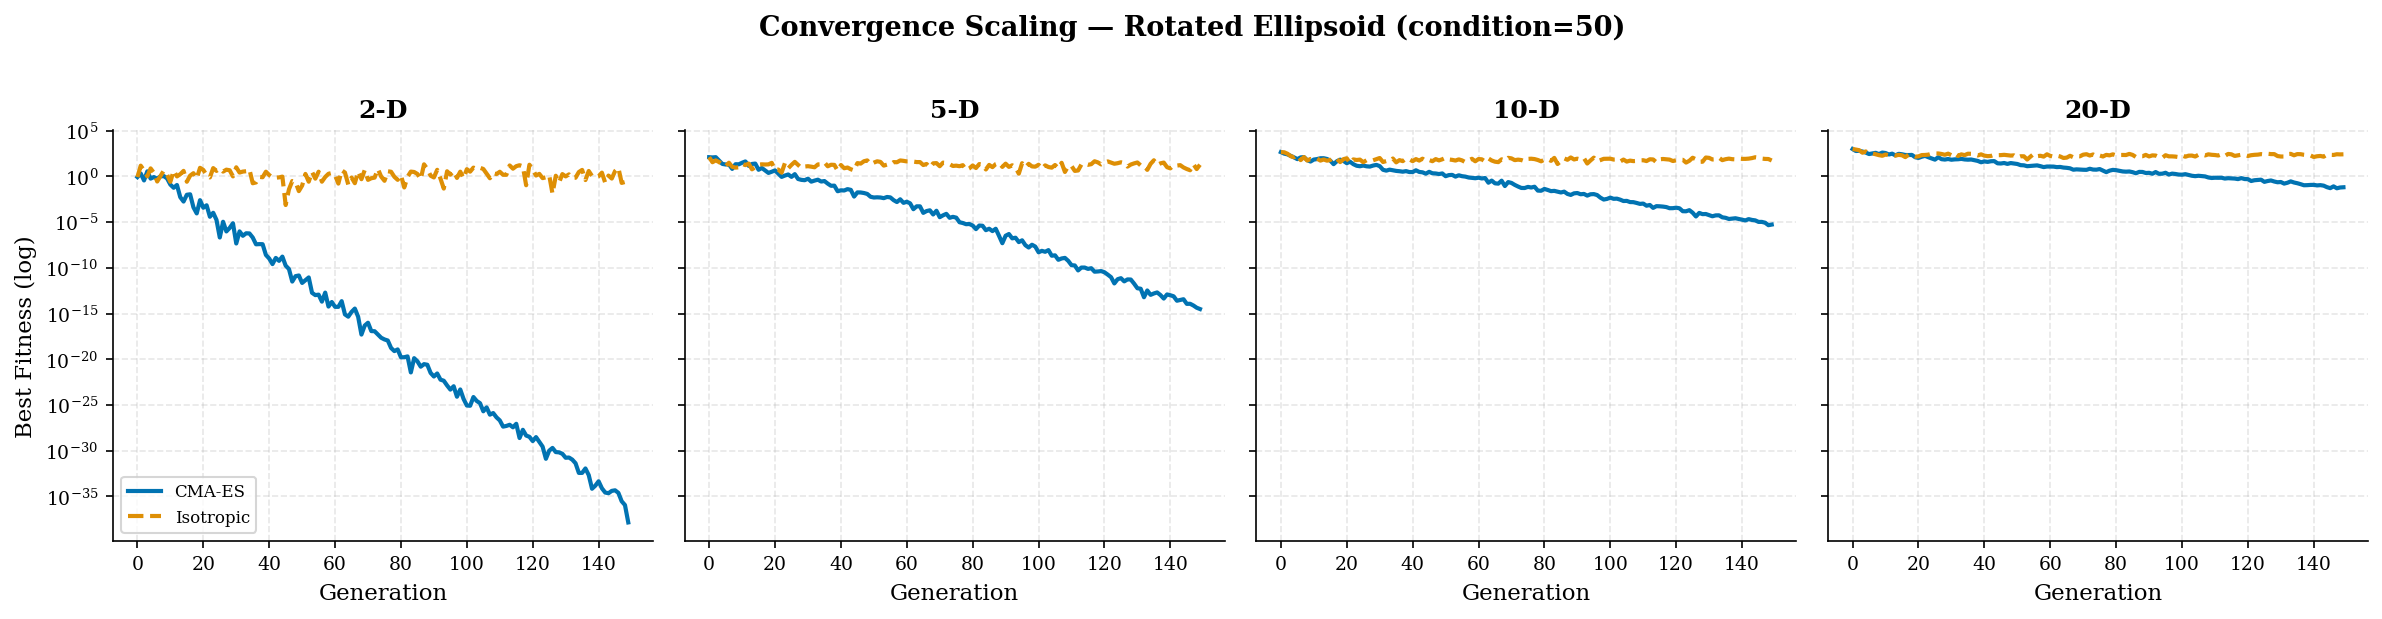

In [19]:
# ── Figure 10: Scaling — convergence per dimension ────────────────────────
fig, axes = plt.subplots(1, len(dims), figsize=(16, 4), sharey=True)

for ax, d in zip(axes, dims):
    for algo, color, ls in [('CMA-ES', PALETTE[0], '-'), ('Isotropic', PALETTE[1], '--')]:
        mask = (df_scale['dim'] == d) & (df_scale['algo'] == algo)
        sub = df_scale[mask]
        ax.semilogy(sub['gen'], sub['best_f'], color=color, linewidth=2,
                    linestyle=ls, label=algo)
    ax.set_xlabel('Generation')
    ax.set_title(f'{d}-D', fontweight='bold')
    if d == dims[0]:
        ax.set_ylabel('Best Fitness (log)')
        ax.legend(fontsize=8)

fig.suptitle('Convergence Scaling — Rotated Ellipsoid (condition=50)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## 8. Anatomy of the Covariance Update

To really see *how* $C$ adapts, let's visualise the **eigenvectors** of the covariance
matrix as arrows that show the search directions, and the **eigenvalues** as their
lengths. This makes the rotation and stretching concrete.

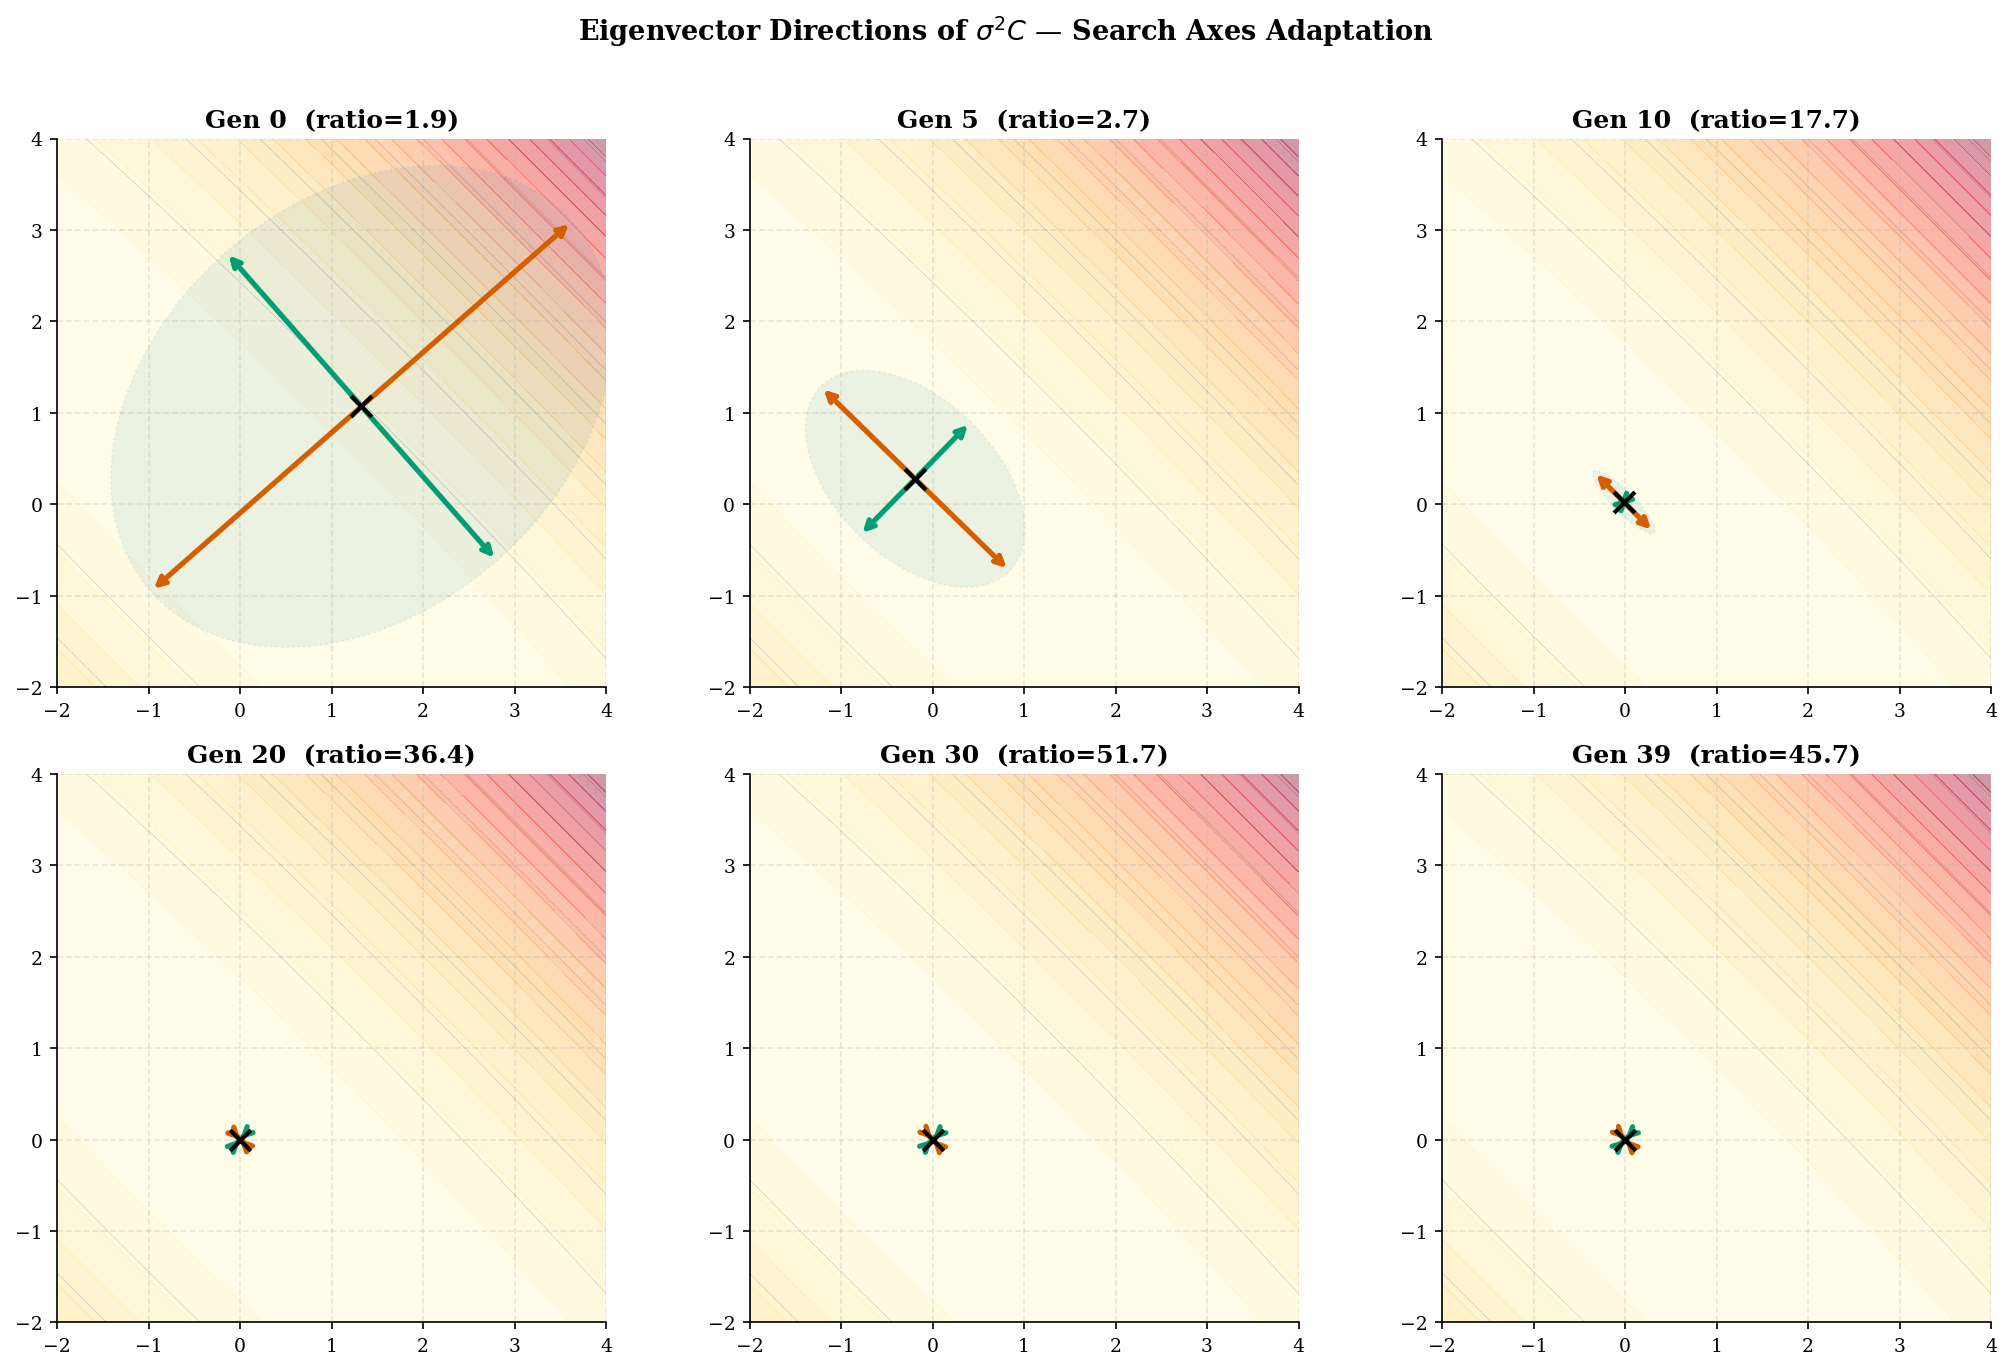

In [20]:
# ── Figure 11: Eigenvector arrows showing search direction adaptation ─────
show_gens_eig = [0, 5, 10, 20, 30, 39]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

grid = np.linspace(-3, 4, 300)
X, Y = np.meshgrid(grid, grid)
Z = rotated_ellipsoid(np.c_[X.ravel(), Y.ravel()]).reshape(X.shape)

for ax, g in zip(axes.flat, show_gens_eig):
    h = cma.history[g]
    ax.contourf(X, Y, Z, levels=25, cmap='YlOrRd', alpha=0.4)
    ax.contour(X, Y, Z, levels=10, colors='k', linewidths=0.2, alpha=0.3)

    m = h['mean']
    C = h['C'] * h['sigma']**2
    eigvals, eigvecs = np.linalg.eigh(C)

    # Draw eigenvectors as arrows scaled by sqrt(eigenvalue)
    for i, (val, vec) in enumerate(zip(eigvals, eigvecs.T)):
        scale = 2 * np.sqrt(val)
        color = PALETTE[2] if i == 0 else PALETTE[3]
        ax.annotate('', xy=m + scale * vec, xytext=m,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.annotate('', xy=m - scale * vec, xytext=m,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))

    cov_ellipse(m, C, ax, n_std=2,
                facecolor=PALETTE[0], alpha=0.08, edgecolor=PALETTE[0],
                linewidth=1, linestyle=':')
    ax.scatter(*m, marker='x', s=100, color='k', linewidths=2, zorder=5)

    ratio = eigvals.max() / max(eigvals.min(), 1e-20)
    ax.set_title(f'Gen {g}  (ratio={ratio:.1f})', fontweight='bold')
    ax.set_xlim(-2, 4); ax.set_ylim(-2, 4)
    ax.set_aspect('equal')

fig.suptitle('Eigenvector Directions of $\\sigma^2 C$ — Search Axes Adaptation',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Figure 12 — Evolution Path Visualisation

The evolution paths $p_\sigma$ and $p_c$ are the "memory" of CMA-ES. Let's
plot their norms over time to see how momentum builds and decays.

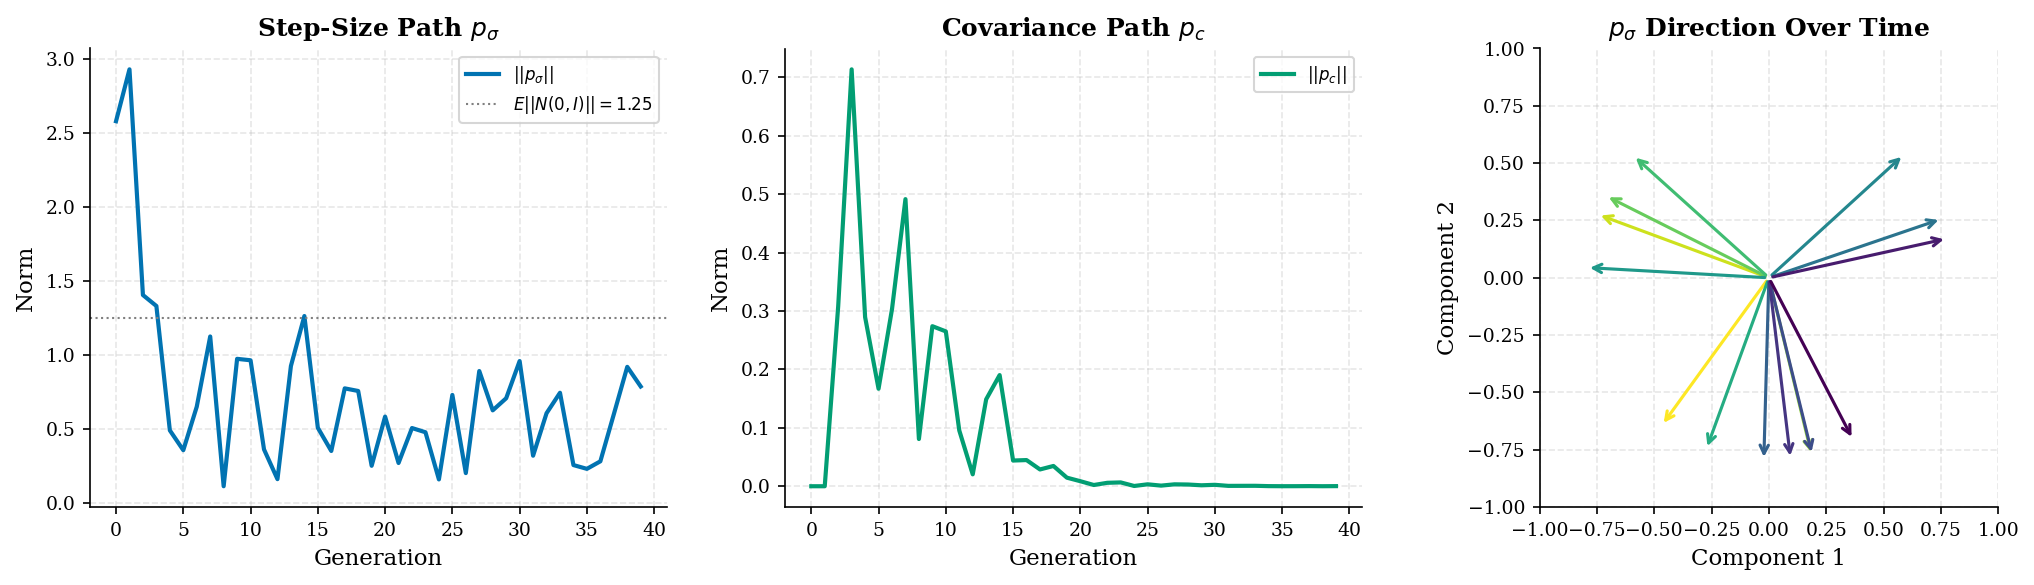

In [21]:
# ── Rerun CMA-ES but save evolution paths ─────────────────────────────────
# Extend the class to also record paths
class CMA_ES_Paths(CMA_ES):
    def _record(self, gen, population, fitness):
        super()._record(gen, population, fitness)
        self.history[-1]['p_sigma'] = self.p_sigma.copy()
        self.history[-1]['p_c'] = self.p_c.copy()

cma_paths = CMA_ES_Paths(mean=[2.0, 2.0], sigma=1.0, lam=20, seed=42)
cma_paths.run(rotated_ellipsoid, n_generations=40)

# ── Figure 12: Evolution path norms ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

gens_p = [h['gen'] for h in cma_paths.history]
ps_norms = [np.linalg.norm(h['p_sigma']) for h in cma_paths.history]
pc_norms = [np.linalg.norm(h['p_c']) for h in cma_paths.history]

ax = axes[0]
ax.plot(gens_p, ps_norms, color=PALETTE[0], linewidth=2, label='$||p_\\sigma||$')
ax.axhline(cma_paths.chi_n, color='grey', linestyle=':', linewidth=1,
           label=f'$E||N(0,I)|| = {cma_paths.chi_n:.2f}$')
ax.set_xlabel('Generation'); ax.set_ylabel('Norm')
ax.set_title('Step-Size Path $p_\\sigma$', fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(gens_p, pc_norms, color=PALETTE[2], linewidth=2, label='$||p_c||$')
ax.set_xlabel('Generation'); ax.set_ylabel('Norm')
ax.set_title('Covariance Path $p_c$', fontweight='bold')
ax.legend(fontsize=8)

# (c) 2D arrow plot of p_sigma direction over time
ax = axes[2]
for i, h in enumerate(cma_paths.history[::3]):
    ps = h['p_sigma']
    norm = np.linalg.norm(ps) + 1e-12
    color = plt.cm.viridis_r(i / (len(cma_paths.history) // 3))
    ax.annotate('', xy=ps / norm * 0.8, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.set_title('$p_\\sigma$ Direction Over Time', fontweight='bold')
ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')

fig.tight_layout()
plt.show()